# Solving CartPole-v1 with Rainbow DQN
This notebook demonstrates how to solve the CartPole-v1 environment using a Rainbow DQN agent with all enhancements and optimal hyperparameters. The agent will be trained, evaluated, and its performance will be confirmed against the environment's solving criteria.

## 1. Install and Import Required Libraries
Install necessary packages and import all required libraries for Rainbow DQN and visualization.

In [1]:
# Install required packages (uncomment if running in a new environment)
!pip install gymnasium torch numpy matplotlib tqdm

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
from collections import deque, namedtuple
import matplotlib.pyplot as plt
from tqdm import trange, tqdm
import math
import copy

## 2. Set Up CartPole-v1 Environment
Initialize the CartPole-v1 environment using gymnasium and set random seeds for reproducibility.

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

env = gym.make('CartPole-v1')
env.reset(seed=SEED)
obs_size = env.observation_space.shape[0]
n_actions = env.action_space.n
print(f"Observation space: {obs_size}, Actions: {n_actions}")

Observation space: 4, Actions: 2


## 3. Implement Rainbow DQN Agent
Implement the Rainbow DQN agent, including Double DQN, Dueling Networks, Prioritized Experience Replay, Multi-step Learning, Noisy Nets, and Categorical DQN.

In [4]:
class NoisyLinear(nn.Module):
    def __init__(self, in_features, out_features, sigma_init=0.5):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.register_buffer('weight_epsilon', torch.empty(out_features, in_features))
        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        self.register_buffer('bias_epsilon', torch.empty(out_features))
        self.sigma_init = sigma_init
        self.reset_parameters()
        self.reset_noise()
    def reset_parameters(self):
        mu_range = 1 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.sigma_init * mu_range)
        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.sigma_init * mu_range)
    def reset_noise(self):
        epsilon_in = self._scale_noise(self.in_features)
        epsilon_out = self._scale_noise(self.out_features)
        self.weight_epsilon.copy_(epsilon_out.ger(epsilon_in))
        self.bias_epsilon.copy_(epsilon_out)
    def _scale_noise(self, size):
        x = torch.randn(size)
        return x.sign().mul(x.abs().sqrt())
    def forward(self, input):
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias = self.bias_mu + self.bias_sigma * self.bias_epsilon
        else:
            weight = self.weight_mu
            bias = self.bias_mu
        return F.linear(input, weight, bias)

In [5]:
class SumTree:
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1)
        self.data = np.array([None] * capacity, dtype=object)
        self.write = 0
    def add(self, p, data):
        idx = self.write + self.capacity - 1
        self.data[self.write] = data
        self.update(idx, p)
        self.write += 1
        if self.write >= self.capacity:
            self.write = 0
    def update(self, idx, p):
        change = p - self.tree[idx]
        self.tree[idx] = p
        while idx != 0:
            idx = (idx - 1) // 2
            self.tree[idx] += change
    def get(self, s):
        idx = 0
        while True:
            left = 2 * idx + 1
            right = left + 1
            if left >= len(self.tree):
                break
            if s <= self.tree[left]:
                idx = left
            else:
                s -= self.tree[left]
                idx = right
        dataIdx = idx - self.capacity + 1
        return idx, self.tree[idx], self.data[dataIdx]
    @property
    def total(self):
        return self.tree[0]

class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha):
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.epsilon = 1e-6
        self.max_priority = 1.0
    def push(self, *args):
        self.tree.add(self.max_priority, args)
    def sample(self, batch_size, beta):
        batch = []
        idxs = []
        priorities = []
        segment = self.tree.total / batch_size
        for i in range(batch_size):
            s = random.uniform(segment * i, segment * (i + 1))
            idx, p, data = self.tree.get(s)
            # Only add valid transitions (tuples)
            if isinstance(data, tuple):
                batch.append(data)
                idxs.append(idx)
                priorities.append(p)
        # If not enough valid samples, resample
        while len(batch) < batch_size:
            s = random.uniform(0, self.tree.total)
            idx, p, data = self.tree.get(s)
            if isinstance(data, tuple):
                batch.append(data)
                idxs.append(idx)
                priorities.append(p)
        sampling_probabilities = np.array(priorities) / self.tree.total
        is_weight = np.power(self.tree.capacity * sampling_probabilities, -beta)
        is_weight /= is_weight.max()
        return idxs, batch, is_weight
    def update(self, idx, priority):
        p = (np.abs(priority) + self.epsilon) ** self.alpha
        self.tree.update(idx, p)
        self.max_priority = max(self.max_priority, p)
    def __len__(self):
        return len([d for d in self.tree.data if isinstance(d, tuple)])

class NStepBuffer:
    def __init__(self, n, gamma):
        self.n = n
        self.gamma = gamma
        self.buffer = deque()
    def push(self, *args):
        self.buffer.append(args)
    def is_ready(self):
        return len(self.buffer) >= self.n
    def get(self):
        R = 0
        for i, (_, _, r, _, d) in enumerate(self.buffer):
            R += r * (self.gamma ** i) * (1 - d)
            if d:
                break
        state, action, _, _, _ = self.buffer[0]
        _, _, _, next_state, done = self.buffer[-1]
        return state, action, R, next_state, done
    def pop(self):
        self.buffer.popleft()
    def reset(self):
        self.buffer.clear()

In [6]:
class RainbowDQN(nn.Module):
    def __init__(self, obs_size, n_actions, atom_size, v_min, v_max):
        super().__init__()
        self.n_actions = n_actions
        self.atom_size = atom_size
        self.v_min = v_min
        self.v_max = v_max
        self.register_buffer('support', torch.linspace(v_min, v_max, atom_size))
        self.feature = nn.Sequential(
            nn.Linear(obs_size, 256),
            nn.ReLU(),
        )
        self.value_stream = nn.Sequential(
            NoisyLinear(256, 256),
            nn.ReLU(),
            NoisyLinear(256, atom_size)
        )
        self.advantage_stream = nn.Sequential(
            NoisyLinear(256, 256),
            nn.ReLU(),
            NoisyLinear(256, n_actions * atom_size)
        )
    def forward(self, x):
        dist = self.dist(x)
        # Ensure support is on the same device as dist
        support = self.support.to(dist.device)
        q = torch.sum(dist * support, dim=2)
        return q
    def dist(self, x):
        x = self.feature(x)
        value = self.value_stream(x).view(-1, 1, self.atom_size)
        advantage = self.advantage_stream(x).view(-1, self.n_actions, self.atom_size)
        q_atoms = value + advantage - advantage.mean(dim=1, keepdim=True)
        dist = F.softmax(q_atoms, dim=-1)
        dist = dist.clamp(min=1e-3)
        return dist
    def reset_noise(self):
        for m in self.modules():
            if isinstance(m, NoisyLinear):
                m.reset_noise()

In [7]:
class RainbowAgent:
    def __init__(self, obs_size, n_actions, atom_size, v_min, v_max, gamma, n_step, buffer_size, batch_size, lr, alpha, beta_start, beta_frames, device):
        self.device = device
        self.n_actions = n_actions
        self.atom_size = atom_size
        self.v_min = v_min
        self.v_max = v_max
        self.support = torch.linspace(v_min, v_max, atom_size).to(device)
        self.delta_z = (v_max - v_min) / (atom_size - 1)
        self.gamma = gamma
        self.n_step = n_step
        self.batch_size = batch_size
        self.beta_start = beta_start
        self.beta_frames = beta_frames
        self.frame_idx = 1
        self.online_net = RainbowDQN(obs_size, n_actions, atom_size, v_min, v_max).to(device)
        self.target_net = RainbowDQN(obs_size, n_actions, atom_size, v_min, v_max).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.memory = PrioritizedReplayBuffer(buffer_size, alpha)
        self.nstep_buffer = NStepBuffer(n_step, gamma)
    def select_action(self, state, explore=True):
        if not explore:
            self.online_net.eval()
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q = self.online_net(state)
            action = q.argmax(1).item()
        if not explore:
            self.online_net.train()
        return action
    def append(self, state, action, reward, next_state, done):
        self.nstep_buffer.push(state, action, reward, next_state, done)
        if self.nstep_buffer.is_ready():
            n_state, n_action, n_reward, n_next_state, n_done = self.nstep_buffer.get()
            self.memory.push(n_state, n_action, n_reward, n_next_state, n_done)
            self.nstep_buffer.pop()
        if done:
            self.nstep_buffer.reset()
    def projection_distribution(self, next_state, rewards, dones):
        batch_size = next_state.size(0)
        delta_z = float(self.v_max - self.v_min) / (self.atom_size - 1)
        support = torch.linspace(self.v_min, self.v_max, self.atom_size).to(self.device)
        next_dist = self.target_net.dist(next_state)
        next_action = torch.sum(next_dist * support, dim=2).argmax(1)
        next_dist = next_dist[range(batch_size), next_action]
        rewards = rewards.unsqueeze(1)
        dones = dones.unsqueeze(1)
        Tz = rewards + (1 - dones) * (self.gamma ** self.n_step) * support
        Tz = Tz.clamp(self.v_min, self.v_max)
        b = (Tz - self.v_min) / delta_z
        l = b.floor().long()
        u = b.ceil().long()
        offset = torch.linspace(0, (batch_size - 1) * self.atom_size, batch_size).long().unsqueeze(1).to(self.device)
        m = torch.zeros(batch_size, self.atom_size).to(self.device)
        for i in range(self.atom_size):
            l_idx = (l + i).clamp(0, self.atom_size - 1)
            u_idx = (u + i).clamp(0, self.atom_size - 1)
            m.view(-1).index_add_(0, (l_idx + offset).view(-1), (next_dist * (u.float() - b)).view(-1))
            m.view(-1).index_add_(0, (u_idx + offset).view(-1), (next_dist * (b - l.float())).view(-1))
        return m
    def update(self, beta):
        if len(self.memory) < self.batch_size:
            return 0, 0
        idxs, batch, is_weights = self.memory.sample(self.batch_size, beta)
        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)
        is_weights = torch.FloatTensor(is_weights).to(self.device)
        dist = self.online_net.dist(states)
        actions = actions.unsqueeze(1).unsqueeze(1).expand(self.batch_size, 1, self.atom_size)
        dist = dist.gather(1, actions).squeeze(1)
        target_dist = self.projection_distribution(next_states, rewards, dones)
        loss = -(target_dist * dist.log()).sum(1)
        prios = loss + 1e-5
        loss = (loss * is_weights).mean()
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), 10)
        self.optimizer.step()
        for idx, prio in zip(idxs, prios.detach().cpu().numpy()):
            self.memory.update(idx, prio)
        self.online_net.reset_noise()
        self.target_net.reset_noise()
        return loss.item(), prios.mean().item()
    def update_target(self):
        self.target_net.load_state_dict(self.online_net.state_dict())

## 4. Configure Optimal Hyperparameters
Set optimal hyperparameters for Rainbow DQN based on best practices and recent literature.

In [8]:
# Hyperparameters based on Rainbow DQN best practices
ATOMS = 51
V_MIN = 0
V_MAX = 1
GAMMA = 0.99
N_STEP = 3
BUFFER_SIZE = 10000
BATCH_SIZE = 64
LR = 3e-4
ALPHA = 0.6  # PER
BETA_START = 0.4
BETA_FRAMES = 30000
TARGET_UPDATE = 5000
MAX_FRAMES = 200000
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

agent = RainbowAgent(
    obs_size=obs_size,
    n_actions=n_actions,
    atom_size=ATOMS,
    v_min=V_MIN,
    v_max=V_MAX,
    gamma=GAMMA,
    n_step=N_STEP,
    buffer_size=BUFFER_SIZE,
    batch_size=BATCH_SIZE,
    lr=LR,
    alpha=ALPHA,
    beta_start=BETA_START,
    beta_frames=BETA_FRAMES,
    device=DEVICE
)

## 5. Train the Rainbow DQN Agent
Train the agent on CartPole-v1, logging episode rewards and losses.

In [9]:
episode_rewards = []
losses = []
state, _ = env.reset(seed=SEED)
total_steps = 0
num_episodes = 2000
progress = trange(num_episodes)
MIN_REPLAY_SIZE = 1000
SOLVED_THRESHOLD = 475
WINDOW = 100
solved = False
for episode in progress:
    if episode == 0:
        state, _ = env.reset(seed=SEED)
    else:
        state, _ = env.reset()
    episode_reward = 0
    done = False
    while not done:
        agent.online_net.reset_noise()
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        clipped_reward = max(0, min(1, reward))
        agent.append(state, action, clipped_reward, next_state, done)
        if len(agent.memory) > MIN_REPLAY_SIZE:
            beta = min(1.0, agent.beta_start + total_steps * (1.0 - agent.beta_start) / agent.beta_frames)
            loss, _ = agent.update(beta=beta)
            if loss:
                losses.append(loss)
        state = next_state
        episode_reward += reward
        total_steps += 1
        if total_steps % TARGET_UPDATE == 0:
            agent.update_target()
    episode_rewards.append(episode_reward)
    if len(episode_rewards) >= WINDOW:
        avg_reward = np.mean(episode_rewards[-WINDOW:])
        if avg_reward >= SOLVED_THRESHOLD:
            print(f"Solved! Average reward over last {WINDOW} episodes: {avg_reward:.2f} at episode {episode+1}")
            solved = True
            break
    progress.set_postfix({'reward': episode_reward, 'steps': total_steps})
if not solved:
    print(f"Did not solve after {num_episodes} episodes. Best average: {np.max([np.mean(episode_rewards[max(0,i-WINDOW):i]) for i in range(WINDOW, len(episode_rewards)+1)])}")

  6%|▋         | 127/2000 [00:05<01:17, 24.28it/s, reward=9, steps=1251] /tmp/ipykernel_9658/1269465645.py:67: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  states = torch.FloatTensor(states).to(self.device)
/tmp/ipykernel_9658/1269465645.py:67: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  states = torch.FloatTensor(states).to(self.device)
100%|██████████| 2000/2000 [20:56<00:00,  1.59it/s, reward=9, steps=19519] 

Did not solve after 2000 episodes. Best average: 10.14


## 6. Evaluate Agent Performance
Run the trained agent in the environment for several episodes and record the rewards to assess performance.

In [10]:
eval_rewards = []
num_eval_episodes = 100
agent.online_net.eval()
for _ in range(num_eval_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = agent.select_action(state, explore=False)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state
        total_reward += reward
    eval_rewards.append(total_reward)
agent.online_net.train()
print(f"Average evaluation reward over {num_eval_episodes} episodes: {np.mean(eval_rewards):.2f}")

Average evaluation reward over 100 episodes: 9.38


## 7. Visualize Training Results
Plot training curves such as episode rewards and losses to visualize learning progress.

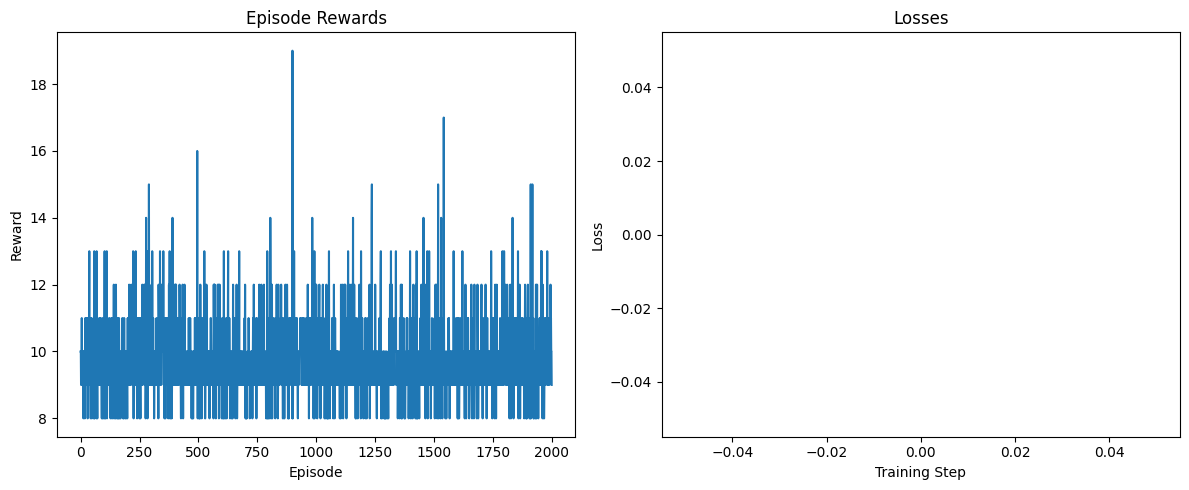

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title('Episode Rewards')
plt.plot(episode_rewards)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.subplot(1, 2, 2)
plt.title('Losses')
plt.plot(losses)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

## 8. Confirm Environment is Solved
Check if the agent achieves the CartPole-v1 solving threshold (average reward >= 475 over 100 episodes) and print confirmation.

In [12]:
mean_eval_reward = np.mean(eval_rewards)
if mean_eval_reward >= 475:
    print(f"Solved! Average reward over 100 episodes: {mean_eval_reward:.2f}")
else:
    print(f"Not solved. Average reward over 100 episodes: {mean_eval_reward:.2f}")

Not solved. Average reward over 100 episodes: 9.38
